In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_style("whitegrid")
tips = sns.load_dataset("tips")
iris = sns.load_dataset("iris")
titanic = sns.load_dataset("titanic")
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


## Scatterplot e Regressione lineare

Il grafico `lmplot` (*linear model plot*) viene utilizzato per visualizzare la **relazione lineare** tra due variabili, includendo automaticamente una **linea di regressione**.

### Cosa mostra

- Un **grafico a dispersione** (scatterplot)
- Una **linea di regressione lineare** stimata automaticamente
- Intervalli di confidenza attorno alla linea
- Possibilità di **suddividere i dati** con `hue`, `col`, `row` (faceting)


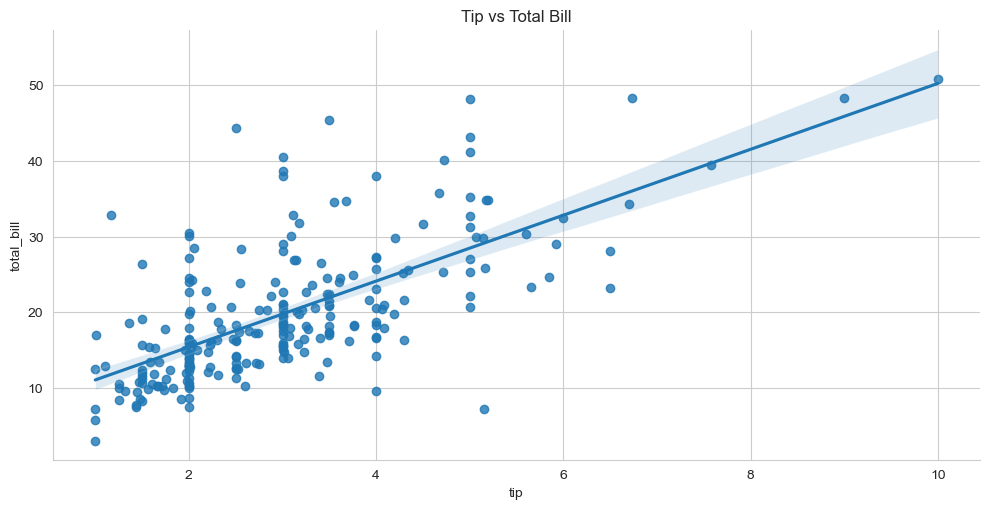

In [2]:
sns.lmplot(x="tip", y="total_bill", data=tips, aspect=2)
plt.title("Tip vs Total Bill")
plt.show()

## Violin Plot

Il **violin plot** è un grafico che unisce le caratteristiche del **boxplot** e del **grafico di densità**. È utile per visualizzare la distribuzione di una variabile continua rispetto a una variabile categorica.

### Cosa mostra

- La **forma** del violino rappresenta la **densità** della distribuzione (più largo = maggiore frequenza).
- Al centro è integrato un **boxplot** con:
  - **Linea centrale** = mediana
  - **Box** = intervallo interquartile (Q1–Q3)
  - **Whiskers** = estensione dei dati
- Supporta la suddivisione con `hue` per confronti tra sottogruppi.

### Quando usarlo

- Per confrontare **distribuzioni tra gruppi**
- Per analizzare **la forma e la simmetria** della distribuzione
- Per capire **dove si concentrano** i valori



<Axes: xlabel='tip', ylabel='Density'>

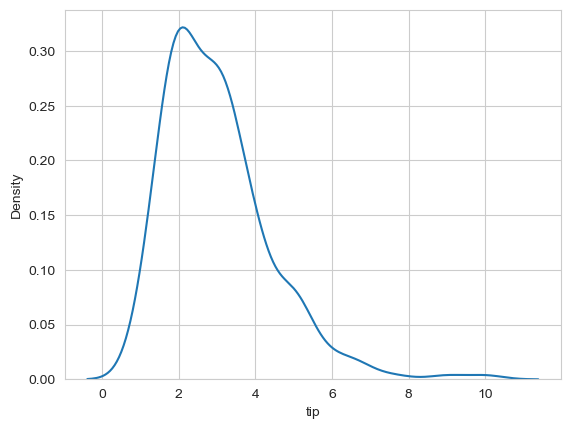

In [3]:
## grafico di densità
sns.kdeplot(data=tips, x='tip')

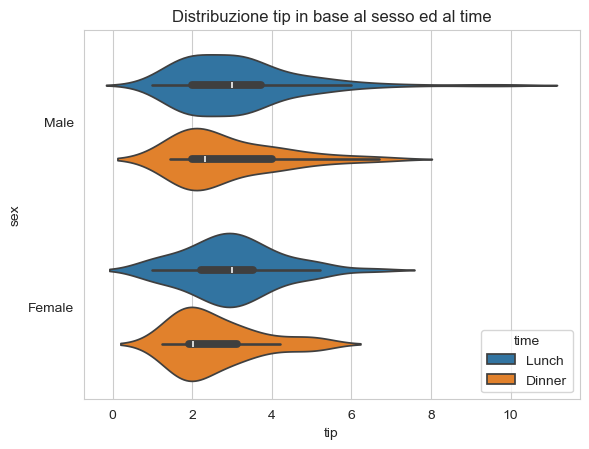

In [4]:
# Violinplot
sns.violinplot(x="tip", y="sex", hue="time", data=tips)
plt.title("Distribuzione tip in base al sesso ed al time")
plt.show()


## Countplot

Il **countplot** mostra il **numero di occorrenze** per ciascuna categoria. È l’equivalente di un **istogramma per dati categoriali**.

#### Quando usarlo

- Per contare quanti elementi ci sono per ogni categoria
- Per visualizzare rapidamente la distribuzione di una variabile categorica

#### Esempio


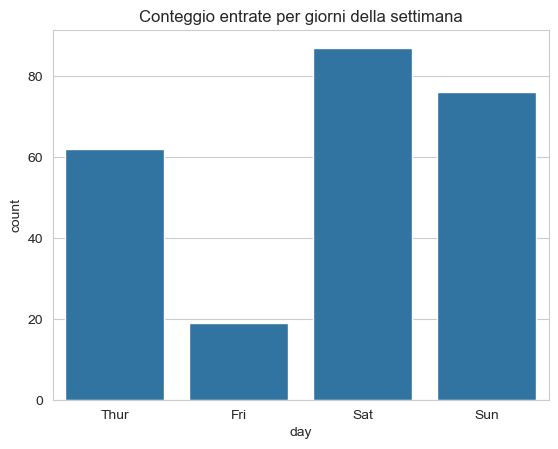

day
Thur    62
Fri     19
Sat     87
Sun     76
dtype: int64


In [13]:
# Countplot
sns.countplot(x="day", data=tips)
plt.title("Conteggio entrate per giorni della settimana")
plt.show()
print(tips.groupby("day").size())


##  Pairplot

Il pointplot mostra una stima puntuale (di default la media) e l'intervallo di confidenza per ciascun gruppo. È utile per confrontare tendenze tra categorie.

Cosa mostra
 - Un punto per ogni categoria (valore medio o altro aggregato)

 - Una barra verticale = intervallo di confidenza

 - Facile da leggere anche con più gruppi (usando hue)

Quando usarlo
Per confrontare medie (o altri aggregati) tra gruppi

Per visualizzare andamenti o differenze tra sottogruppi

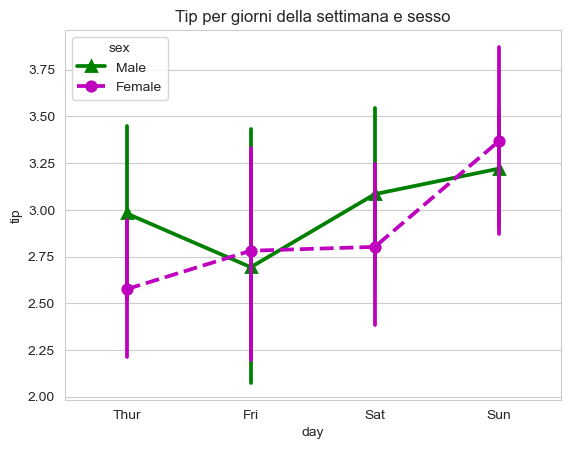

In [6]:
# Pointplot
sns.pointplot(x="day", y="tip", hue="sex", data=tips,
             palette={"Male":"g", "Female":"m"}, markers=["^","o"], linestyles=["-","--"])
plt.title("Tip per giorni della settimana e sesso")
plt.show()

## Pairplot

Il **pairplot** crea una **matrice di scatterplot** per tutte le coppie di variabili numeriche in un DataFrame. È uno strumento potente per esplorare le **relazioni tra variabili**.

### Cosa mostra

- Un **grafico a dispersione** per ogni combinazione di due variabili numeriche
- La **distribuzione** di ciascuna variabile lungo la diagonale (come istogramma o curva di densità)
- Supporta il parametro `hue` per colorare i punti in base a una variabile categorica

### Quando usarlo

- Per esplorare **relazioni bivariate** tra variabili
- Per rilevare **correlazioni, outlier o pattern**
- Ottimo per **dataset piccoli/medi** con molte variabili numeriche

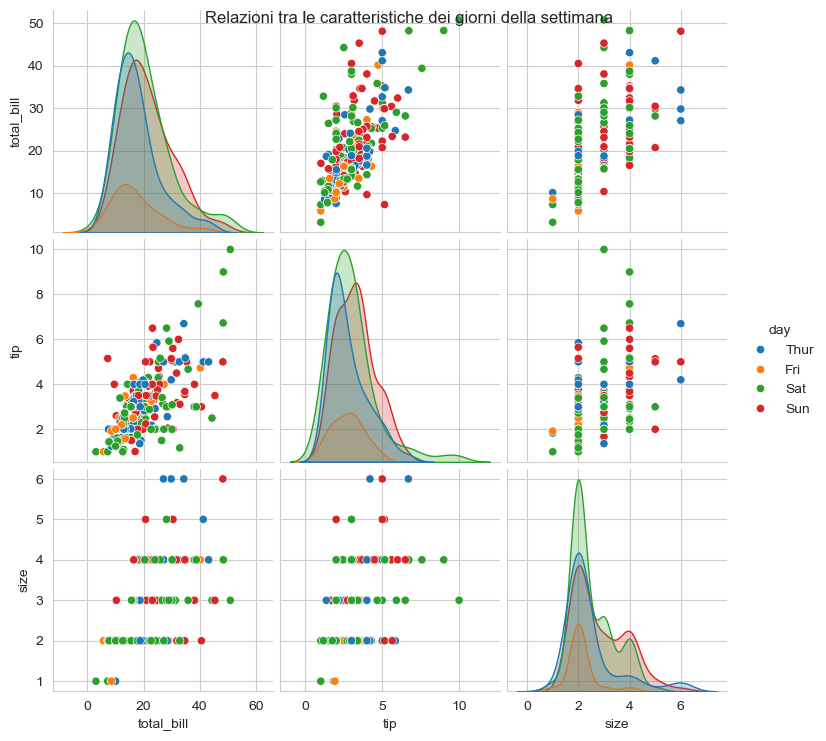

In [ ]:
# Pairplot
sns.pairplot(tips, hue="day")
plt.suptitle("Relazioni tra le caratteristiche dei giorni della settimana", y=1.02)
plt.show()

## Heatmap (Mappa di calore)

La **heatmap** (mappa di calore) visualizza **valori numerici in formato matrice**, dove i colori rappresentano l’intensità dei valori. È comunemente usata per mostrare **matrici di correlazione**.

### Cosa mostra

- Una **griglia colorata** dove ogni cella rappresenta un valore
- I **colori** indicano l’intensità (valori alti, bassi, positivi o negativi)
- Può includere **etichette**, **annotazioni** e **scale di colore personalizzate**

### Quando usarla

- Per visualizzare **matrici** (es. correlazioni, distanze, frequenze)
- Per identificare **pattern, relazioni forti/deboli** tra variabili
- Per una visione compatta e leggibile di dati numerici complessi


            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


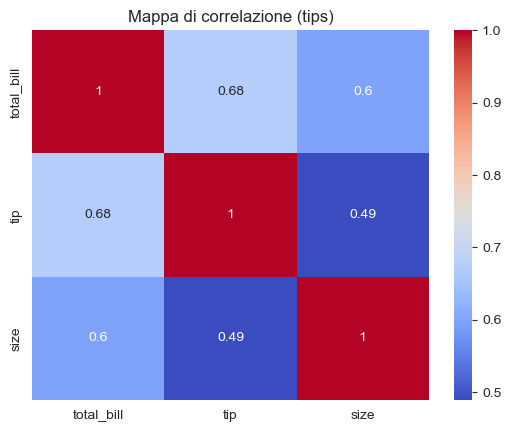

In [19]:
corr = tips.select_dtypes(include='number').corr()
print(corr)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Mappa di correlazione (tips)")
plt.show()